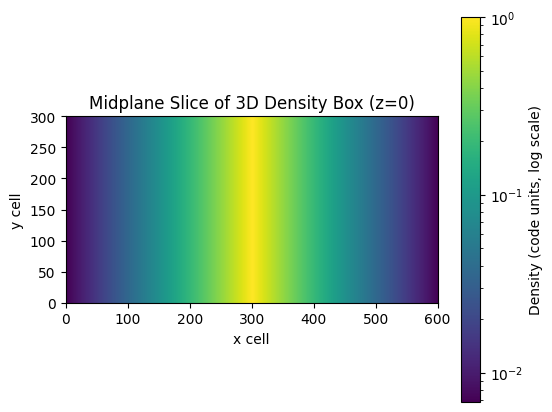

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# -----------------------------
# Box parameters
# -----------------------------
ny = nx = 300
nz = 600
z_start = -5.0
z_end   = 5.0
a       = 0.01      # scale height
rho_fix = 1.0      # density at midplane
P_fix   = 1.0      # pressure at midplane
g0      = 1.0      # gravity unit
z_fix   = 0.0      # midplane

# -----------------------------
# Equation of state (isothermal)
# -----------------------------
def rho_from_P(P):
    return P  # T0 = 1 in code units

# -----------------------------
# Gravity profile
# -----------------------------
def g(z):
    return g0 * (z / a) / np.sqrt(1.0 + (z / a)**2)

# -----------------------------
# RK4 step
# -----------------------------
def rk4_step(z, dz, P, dpdz_fun):
    k1 = dz * dpdz_fun(z, P)
    k2 = dz * dpdz_fun(z + dz/2, P + k1/2)
    k3 = dz * dpdz_fun(z + dz/2, P + k2/2)
    k4 = dz * dpdz_fun(z + dz, P + k3)
    return P + (k1 + 2*k2 + 2*k3 + k4)/6

def dpdz(z, P):
    return -rho_from_P(P) * g(z)

# -----------------------------
# Generate z array and integrate
# -----------------------------
z = np.linspace(z_start, z_end, nz)
P = np.zeros(nz)
P_fix_idx = np.argmin(np.abs(z - z_fix))
P[P_fix_idx] = P_fix
dz = z[1] - z[0]

# Integrate downward
for i in range(P_fix_idx, 0, -1):
    P[i-1] = rk4_step(z[i], -dz, P[i], dpdz)

# Integrate upward
for i in range(P_fix_idx, nz-1):
    P[i+1] = rk4_step(z[i], dz, P[i], dpdz)

# Density profile
rho_1d = rho_from_P(P)

# -----------------------------
# Create 3D density box
# -----------------------------
# Since density only varies along z, we just broadcast it
rho_box = np.zeros((nx, ny, nz))
for k in range(nz):
    rho_box[:, :, k] = rho_1d[k]

# -----------------------------
# Slice through the midplane (z = 0)
# -----------------------------
mid_z_idx = P_fix_idx
rho_slice = rho_box[:, 150, :]

# Plot the slice
plt.figure(figsize=(6,5))
plt.imshow(rho_slice, origin='lower', extent=[0, nz, 0, nx],
           cmap='viridis', norm=LogNorm(vmin=rho_slice.min(), vmax=rho_slice.max()))
plt.colorbar(label='Density (code units, log scale)')
plt.title('Midplane Slice of 3D Density Box (z=0)')
plt.xlabel('x cell')
plt.ylabel('y cell')
plt.show()


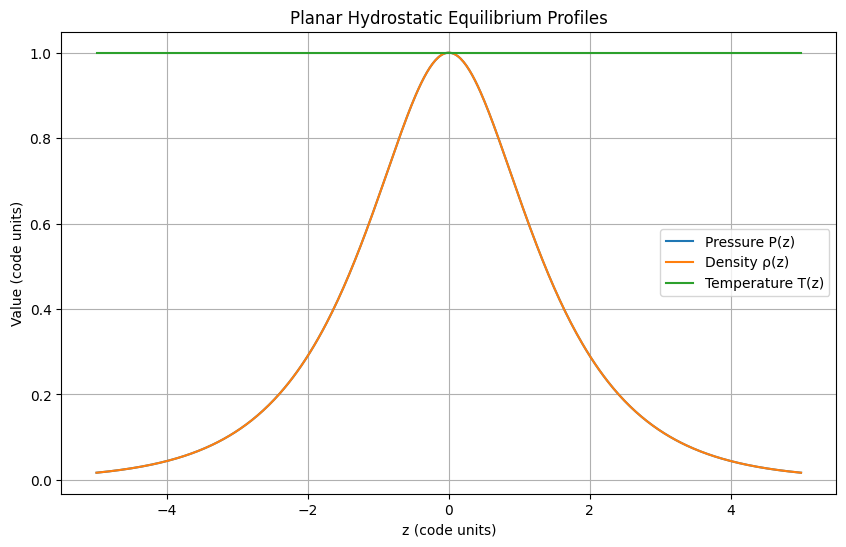

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (code units)
# -----------------------------
z_start = -5.0
z_end   = 5.0
nz      = 500
z_fix   = 0.0      # midplane
P_fix   = 1.0      # midplane pressure
rho_fix = 1.0      # midplane density
T0      = 1.0      # temperature in code units
g0      = 1.0      # gravity scale
a       = 1.0      # scale height

# -----------------------------
# Equation of state
# -----------------------------
def rho_from_P(P, T=T0):
    """Isothermal EOS: rho = P / T"""
    return P / T

def T_from_P(P):
    """Temperature is constant for isothermal case"""
    return T0 * np.ones_like(P)

# -----------------------------
# Gravity profile
# -----------------------------
def g(z):
    return g0 * (z / a) / np.sqrt(1 + (z / a)**2)

# -----------------------------
# RK4 integration
# -----------------------------
def rk4_step(z, dz, P, dpdz_fun):
    k1 = dz * dpdz_fun(z, P)
    k2 = dz * dpdz_fun(z + dz/2, P + k1/2)
    k3 = dz * dpdz_fun(z + dz/2, P + k2/2)
    k4 = dz * dpdz_fun(z + dz, P + k3)
    return P + (k1 + 2*k2 + 2*k3 + k4)/6

def dpdz(z, P):
    return -rho_from_P(P) * g(z)

# -----------------------------
# Generate z array
# -----------------------------
z = np.linspace(z_start, z_end, nz)
P = np.zeros(nz)
P_fix_idx = np.argmin(np.abs(z - z_fix))
P[P_fix_idx] = P_fix

dz = z[1] - z[0]

# -----------------------------
# Integrate downward from midplane
# -----------------------------
for i in range(P_fix_idx, 0, -1):
    P[i-1] = rk4_step(z[i], -dz, P[i], dpdz)

# -----------------------------
# Integrate upward from midplane
# -----------------------------
for i in range(P_fix_idx, nz-1):
    P[i+1] = rk4_step(z[i], dz, P[i], dpdz)

# -----------------------------
# Compute density and temperature
# -----------------------------
rho = rho_from_P(P)
T   = T_from_P(P)

# -----------------------------
# Plot profiles
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(z, P, label='Pressure P(z)')
#plt.plot(z, rho, label='Density ρ(z)')
plt.plot(z, T, label='Temperature T(z)')
plt.xlabel('z (code units)')
plt.ylabel('Value (code units)')
plt.title('Planar Hydrostatic Equilibrium Profiles')
plt.legend()
plt.grid(True)
plt.show()
